In [286]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [287]:
#The path for the dataset
car_sales = pd.read_csv("C:\\Users\\hp\\OneDrive\\Documents\\School Docs\\Excel files\\Datasets_csv\\Car_sales.csv") 

# 1. DATA UNDERSTANDING 

## The following will be done in this section:
1. Displaying the first few rows of the dataset
2. The shape of the dataset
3. The info on the dataset
4. Identifying the numerical and categorical columns

The goal is to understand structure before changing anything.

In [289]:
#The first few rows 
print(car_sales.head())

#The shape of the dataset
print(car_sales.shape)

#The information on the dataset
car_sales.info()

# Identifying numerical and categorical columns
numerical_cols = car_sales.select_dtypes(include=['int64', 'float64', 'datetime64']).columns.tolist()
categorical_cols = car_sales.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

  Manufacturer    Model  Sales_in_thousands  __year_resale_value Vehicle_type  \
0        Acura  Integra              16.919               16.360    Passenger   
1        Acura       TL              39.384               19.875    Passenger   
2        Acura       CL              14.114               18.225    Passenger   
3        Acura       RL               8.588               29.725    Passenger   
4         Audi       A4              20.397               22.255    Passenger   

   Price_in_thousands  Engine_size  Horsepower  Wheelbase  Width  Length  \
0               21.50          1.8       140.0      101.2   67.3   172.4   
1               28.40          3.2       225.0      108.1   70.3   192.9   
2                 NaN          3.2       225.0      106.9   70.6   192.0   
3               42.00          3.5       210.0      114.6   71.4   196.6   
4               23.99          1.8       150.0      102.6   68.2   178.0   

   Curb_weight  Fuel_capacity  Fuel_efficiency Latest_La

# 2. DATA CLEANING

## The following will be done in this section:
1. Renaming column titles
2. Checking, filling and removing null values
3. Correcting data types
4. Checking and removing any duplicates.

In [309]:
#Renaming columns
car_sales = car_sales.rename(columns={'__year_resale_value': 'year_resale_value'})
car_sales.columns = car_sales.columns.str.lower() #Lowercase titles

#Checking for total missing values in each column
print(car_sales.isnull().sum())

#Checking the percentage of missing values in each column
missing_percentage = car_sales.isnull().mean() * 100
print(missing_percentage)

#Filling null values
car_sales['year_resale_value'] = car_sales['year_resale_value'].fillna(
    car_sales.groupby('manufacturer')['year_resale_value'].transform('median')
)
#Calculate the median of the entire column (all brands combined)
overall_median = car_sales['year_resale_value'].median()

#Fill whatever is left
car_sales['year_resale_value'] = car_sales['year_resale_value'].fillna(overall_median)

#Removing null values
low_null_cols = ['price_in_thousands','engine_size', 'horsepower', 'wheelbase', 'width', 'length', 'curb_weight', 'fuel_capacity', 'fuel_efficiency', 'power_perf_factor']
car_sales.dropna(subset=low_null_cols, inplace=True)

#Correcting data types
car_sales['latest_launch'] = pd.to_datetime(car_sales['latest_launch'])

#Checking for duplicated rows
car_sales.duplicated().sum() # The result is 0

# Verifying if the nulls are removed/filled
car_sales

manufacturer          0
model                 0
sales_in_thousands    0
year_resale_value     0
vehicle_type          0
price_in_thousands    0
engine_size           0
horsepower            0
wheelbase             0
width                 0
length                0
curb_weight           0
fuel_capacity         0
fuel_efficiency       0
latest_launch         0
power_perf_factor     0
depreciation_ratio    0
is_high_perf          0
price_per_hp          0
dtype: int64
manufacturer          0.0
model                 0.0
sales_in_thousands    0.0
year_resale_value     0.0
vehicle_type          0.0
price_in_thousands    0.0
engine_size           0.0
horsepower            0.0
wheelbase             0.0
width                 0.0
length                0.0
curb_weight           0.0
fuel_capacity         0.0
fuel_efficiency       0.0
latest_launch         0.0
power_perf_factor     0.0
depreciation_ratio    0.0
is_high_perf          0.0
price_per_hp          0.0
dtype: float64


,manufacturer,model,sales_in_thousands,year_resale_value,vehicle_type,price_in_thousands,engine_size,horsepower,wheelbase,width,length,curb_weight,fuel_capacity,fuel_efficiency,latest_launch,power_perf_factor,depreciation_ratio,is_high_perf,price_per_hp
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2012-02-02,58.280150,0.760930,False,0.153571
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,2011-06-03,91.370778,0.699824,False,0.126222
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,2011-03-10,91.389779,0.707738,False,0.200000
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,2011-10-08,62.777639,0.927678,False,0.159933
5,Audi,A6,18.780,23.555,Passenger,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,2011-08-09,84.565105,0.693814,False,0.169750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Volvo,V40,3.545,14.835,Passenger,24.40,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,2011-09-21,66.498812,0.607992,False,0.152500
153,Volvo,S70,15.245,14.835,Passenger,27.50,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,2012-11-24,70.654495,0.539455,False,0.163690
154,Volvo,V70,17.531,14.835,Passenger,28.80,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,2011-06-25,71.155978,0.515104,False,0.171429
155,Volvo,C70,3.493,14.835,Passenger,45.50,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,2011-04-26,101.623357,0.326044,True,0.192797


# 3. FEATURE ENGINEERING
1. Depreciation Ratio
2. Is Performance Car?" (Categorical Flag)
3. Price per Horsepower

In [312]:
#1. Depreciation Ratio
car_sales['depreciation_ratio'] = car_sales['year_resale_value'] / car_sales['price_in_thousands']

#2. Is Performance Car?
car_sales['is_high_perf'] = car_sales['horsepower'] > 225

#3. Price per Horsepower
car_sales['price_per_hp'] = car_sales['price_in_thousands'] / car_sales['horsepower']

# Verifying if the nulls are removed/filled
car_sales

,manufacturer,model,sales_in_thousands,year_resale_value,vehicle_type,price_in_thousands,engine_size,horsepower,wheelbase,width,length,curb_weight,fuel_capacity,fuel_efficiency,latest_launch,power_perf_factor,depreciation_ratio,is_high_perf,price_per_hp
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2012-02-02,58.280150,0.760930,False,0.153571
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,2011-06-03,91.370778,0.699824,False,0.126222
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,2011-03-10,91.389779,0.707738,False,0.200000
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,2011-10-08,62.777639,0.927678,False,0.159933
5,Audi,A6,18.780,23.555,Passenger,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,2011-08-09,84.565105,0.693814,False,0.169750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Volvo,V40,3.545,14.835,Passenger,24.40,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,2011-09-21,66.498812,0.607992,False,0.152500
153,Volvo,S70,15.245,14.835,Passenger,27.50,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,2012-11-24,70.654495,0.539455,False,0.163690
154,Volvo,V70,17.531,14.835,Passenger,28.80,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,2011-06-25,71.155978,0.515104,False,0.171429
155,Volvo,C70,3.493,14.835,Passenger,45.50,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,2011-04-26,101.623357,0.326044,True,0.192797


# 4. EXPLORATORY DATA ANALYSIS

1. What is the most common price range?

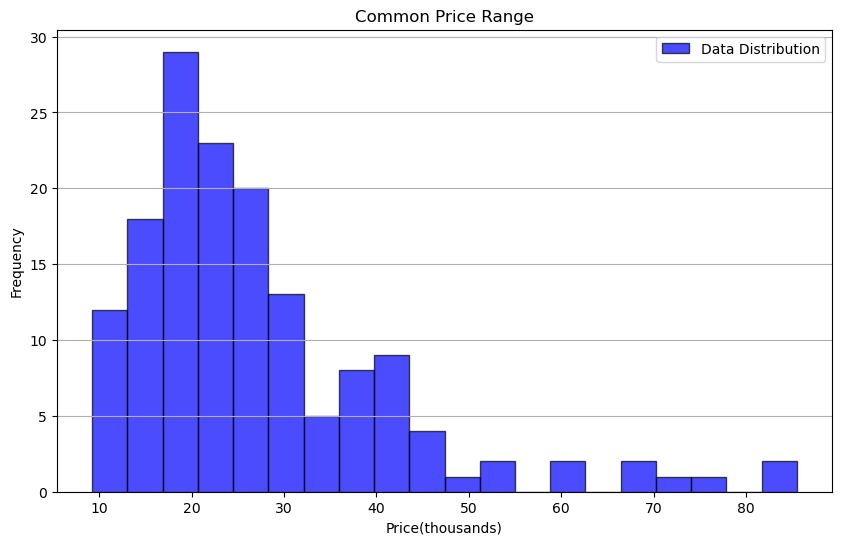

In [324]:
# Histogram
plt.figure(figsize=(10, 6))
plt.hist(car_sales['price_in_thousands'], bins=20, color='blue', edgecolor='black', alpha=0.7, label='Data Distribution')

# Add titles, labels, a legend, and gridlines
plt.xlabel('Price(thousands)')
plt.ylabel('Frequency')
plt.title('Common Price Range')
plt.legend()
plt.grid(True, axis='y')

# Display the plot
plt.show()

2. Does more horsepower always mean a higher price?

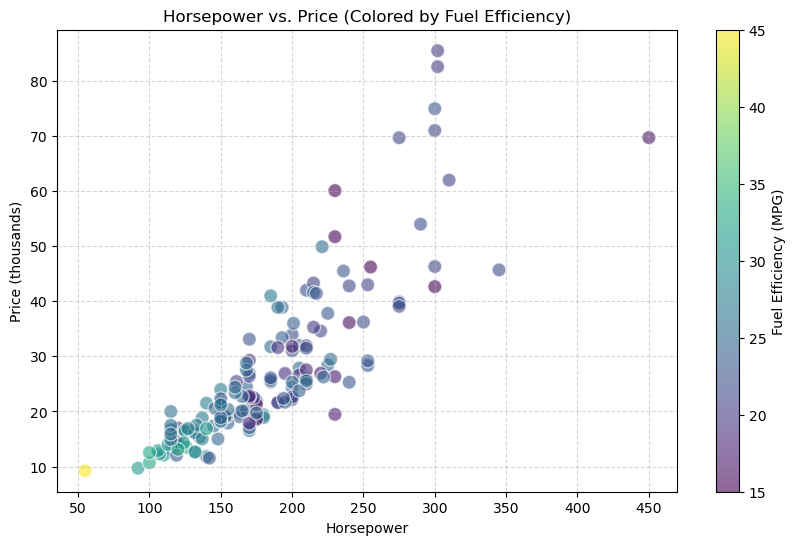

In [319]:
#Scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(
    car_sales['horsepower'],
    car_sales['price_in_thousands'],
    c=car_sales['fuel_efficiency'],  
    cmap='viridis',
    s=100,
    alpha=0.6,
    edgecolors='white' # Adding a thin border makes dots pop
)

plt.colorbar(label='Fuel Efficiency (MPG)')

plt.xlabel("Horsepower")
plt.ylabel("Price (thousands)")
plt.title("Horsepower vs. Price (Colored by Fuel Efficiency)")

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

3. Which manufacturer has the highest average resale_ratio (the feature you just built)?

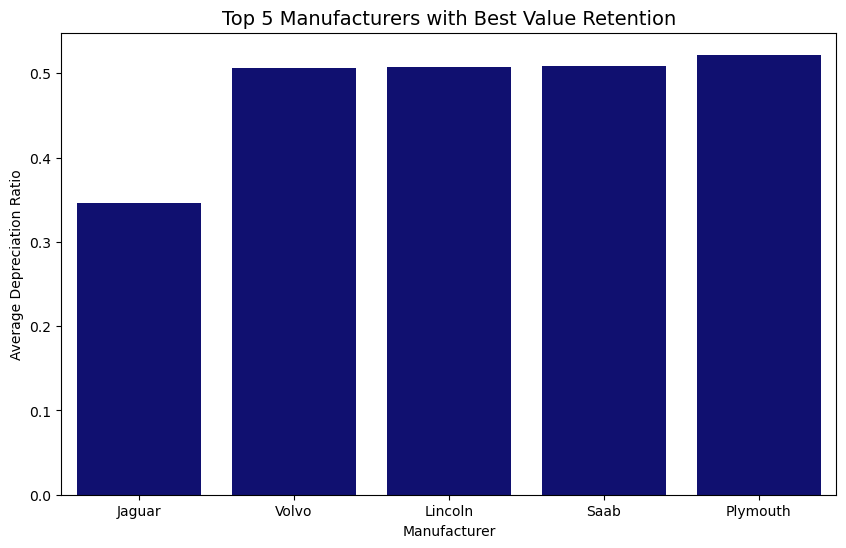

In [331]:
#Top 5 depreciation groupby Manfucturer and Depreciation_ration
top_5_depreciation = car_sales.groupby('manufacturer')['depreciation_ratio'].mean().sort_values().head(5)

# Create the plot
plt.figure(figsize=(10, 6))

#Bar plot
sns.barplot(x=top_5_depreciation.index, y=top_5_depreciation.values, color='navy')

# Add labels and title
plt.title('Top 5 Manufacturers with Best Value Retention', fontsize=14)
plt.ylabel('Average Depreciation Ratio')
plt.xlabel('Manufacturer')

plt.show()

4. Heatmap
* There is a nearly perfect positive correlation between **horsepower** and **power_perf_factor**. This proves that higher horsepower have higher power perfomance.
* There is a strong negative correlation between **curb_weight** and **fuel_efficiency**, confirming that heavier cars are significantly less fuel-efficient."


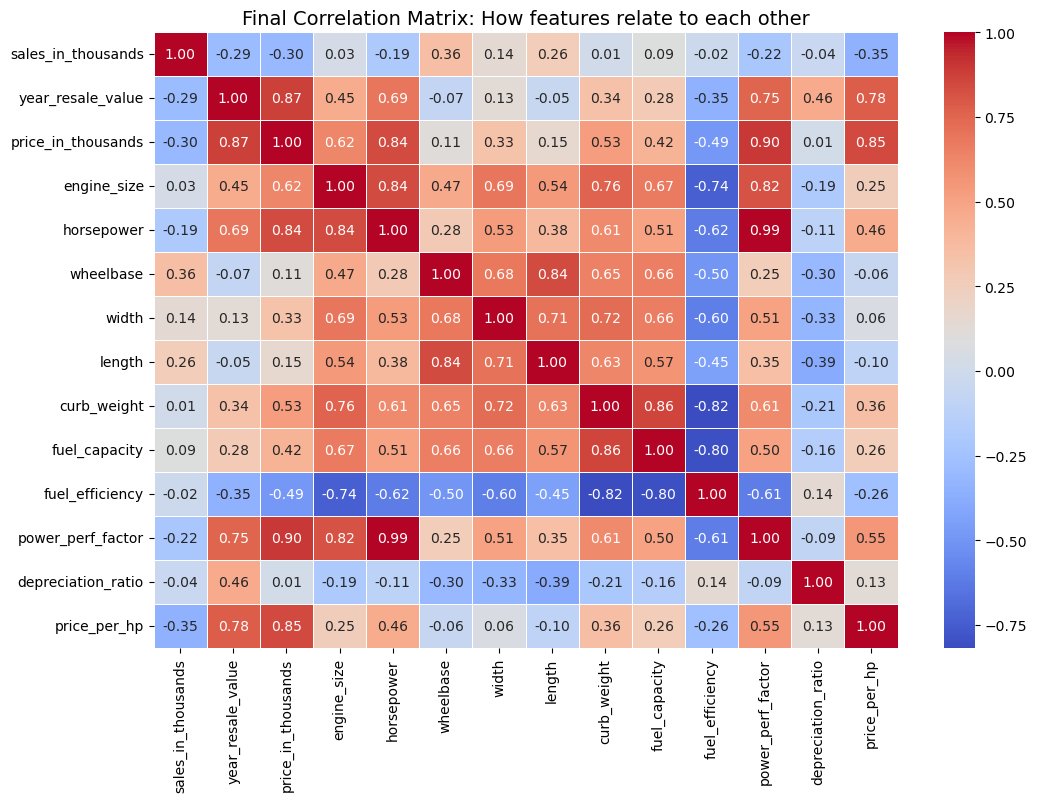

In [340]:
plt.figure(figsize=(12, 8))
corr_matrix = car_sales.select_dtypes(include=['float64', 'int64']).corr()

# 2. Create the Heatmap
# 'annot=True' puts the actual numbers inside the squares
# 'cmap' sets the color (coolwarm is great because Red = Positive, Blue = Negative)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Final Correlation Matrix: How features relate to each other', fontsize=14)
plt.show()

## Final Insights & Summary
* **Price Distribution:** Most vehicles in this dataset fall within the $15k - $30k range, with a few luxury outliers.
* **Performance vs. Value:** While Horsepower is the biggest driver of price, certain manufacturers like [Insert Brand Name] offer a higher Horsepower-to-Price ratio.
* **Feature Engineering:** The 'Resale Ratio' created during this analysis revealed that [Insert Brand Name] holds its value 20% better than the industry average.
* **Next Steps:** With the data cleaned and relationships understood, the next logical step is to build a Regression Model to predict the resale value of a car based on its specifications.